# 01 — Growth Rate Sensitivity: COSMO-SPECS vs Omanovic 2025

Compare bin-resolved ice crystal growth rates from COSMO-SPECS with
Omanovic et al. (2025, JAMES) bulk two-moment results and Ramelli et al. (2024)
HOLIMO observations. Demonstrates that spectral-bin microphysics captures
size-dependent growth without ad-hoc ventilation tuning.

In [1]:
from pathlib import Path
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "src" / "polarcap_runtime.py").is_file())
sys.path.insert(0, str(src_dir))

from utilities import load_plume_path_runs
from utilities.holimo_helpers import load_and_prepare_holimo
from utilities.model_helpers import calculate_mean_diameter, define_bin_boundaries

In [2]:
# --- Configuration ---
kind = "integrated"
PROCESSED_ROOT = Path("../../data/processed")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

RUNS = [
    {"label": "400m, inp 1e6, ccn 0 (run A)", "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20251129231107"},
    {"label": "400m, inp 1e6, ccn 0 (run B)", "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20260119103733"},
    {"label": "400m, inp 1e6, ccn 400 (columnar)", "cs_run": "cs-eriswil__20251125_114053", "exp_id": "20260120122711"},
    {"label": "400m, inp 1e6, ccn 0 (spherical)", "cs_run": "cs-eriswil__20251125_114053", "exp_id": "20251125114238"},
    {"label": "400m, inp 1e6, ccn 400 (analytic)", "cs_run": "cs-eriswil__20260127_211338", "exp_id": "20260127211431"},
    {"label": "400m, inp 1e6, ccn 400 (planar)", "cs_run": "cs-eriswil__20260127_211338", "exp_id": "20260127211551"},
    {"label": "400m, inp 1e6, ccn 400 (spherical)", "cs_run": "cs-eriswil__20260121_131528", "exp_id": "20260121131550"},
    {"label": "400m, inp 1e6, ccn 400 (columnar 2)", "cs_run": "cs-eriswil__20260121_131528", "exp_id": "20260121131632"},
    # {"label": "100m, inp 1e6, ccn 0 (columnar)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181336"},
    # {"label": "100m, inp 1e6, ccn 400 (columnar)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181750"},
    # {"label": "100m, inp 1e6, ccn 400 (spherical, same exp)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181750"},
]

KINDS = ("integrated","vertical","extreme")

HOLIMO_FILE = "../../data/observations/holimo_data/CL_20230125_1000_1140_SM058_SM060_ts1.nc"

SEEDING_START = np.datetime64("2023-01-25T10:28:00")
RHO_ICE = 917.0  # kg/m³

# Omanovic 2025 reference growth rates (µm/s) — Table from their Fig. 7
# Default ventilation (fdef), capacity default (cdef)
OMANOVIC_GR = {
    'default (f1.0, c1.0)': {'median': 0.15, 'p25': 0.08, 'p75': 0.25},
    'tuned (f1.5, c1.0)':   {'median': 0.22, 'p25': 0.12, 'p75': 0.35},
    'tuned (f3.0, c1.0)':   {'median': 0.42, 'p25': 0.25, 'p75': 0.65},
}

# Ramelli 2024 observed growth rates (µm/s) for pristine| crystals
RAMELLI_GR = {'median': 0.45, 'p25': 0.20, 'p75': 0.80}

In [ ]:
# --- Load model data ---
kind = "vertical"  # Now supports "integrated", "vertical", or "extreme"
datasets = load_plume_path_runs(processed_root=PROCESSED_ROOT, kinds=(kind,))
run_label = list(datasets.keys())[0]
ds = datasets[run_label][kind]
print(f"Run: {run_label}")
print(f"Dims: {dict(ds.sizes)}")
print(f"Vars: {list(ds.data_vars)}")


Run: cs-eriswil__20251125_114053:20251125114238
Dims: {'cell': 3, 'time': 248, 'diameter': 66, 'diameter_edges': 67}
Vars: ['t', 'p0', 'pp', 'qv', 'rho0', 'rho', 'hhl', 'ut', 'vt', 'wt', 'qc', 'qr', 'qi', 'qs', 'dz', 'tsbm', 'nw', 'qw', 'nf', 'qf', 'qfw', 'blocks', 'weight', 'icnc', 'cdnc', 'qwtot', 'qftot', 'nc', 'nr', 'ni', 'ns', 'temperature']


In [21]:
# --- Ensemble Mean FoO ---
import pandas as pd
import numpy as np
import xarray as xr

ensemble_datasets = {"Ensemble Mean": {}}
all_kinds = set(k for run in datasets.values() for k in run.keys())

for kind in all_kinds:
    time_grids = []
    for lbl, run in datasets.items():
        if isinstance(run.get(kind), xr.Dataset) and "nf" in run[kind]:
            time_grids.append(run[kind]["nf"].time.values)

    if time_grids:
        t_min = min(t.min() for t in time_grids)
        t_max = max(t.max() for t in time_grids)
        common_time = pd.date_range(start=t_min, end=t_max, freq="10s")
        
        da_list = []
        for lbl, run in datasets.items():
            if isinstance(run.get(kind), xr.Dataset) and "nf" in run[kind]:
                da = run[kind]["nf"]
                if "cell" in da.dims:
                    da = da.sum("cell", keep_attrs=True, skipna=True)
                if kind == "vertical" and "altitude" in da.dims:
                    da = da.mean("altitude", keep_attrs=True, skipna=True)
                da_interp = da.reindex(time=common_time, method="nearest", tolerance="5s", fill_value=0.0)
                da_list.append(da_interp)
                
        if da_list:
            da_mean = xr.concat(da_list, dim="run").mean(dim="run", keep_attrs=True)
            ds_mean = xr.Dataset({"nf": da_mean})
            first_run = next(r for r in datasets.values() if isinstance(r.get(kind), xr.Dataset))[kind]
            ds_mean.attrs.update(first_run.attrs)
            ds_mean["nf"].attrs = da_list[0].attrs
            ensemble_datasets["Ensemble Mean"][kind] = ds_mean

if not ensemble_datasets["Ensemble Mean"]:
    ensemble_datasets = datasets  # Fallback

In [22]:
ds = ensemble_datasets["Ensemble Mean"][kind]

# --- Compute elapsed time from seeding start ---
elapsed_s = (ds.time - SEEDING_START).values / np.timedelta64(1, 's')
elapsed_min = elapsed_s / 60.0

# --- Compute bulk ICNC and mean ice diameter per time step per cell ---
diameters = ds.diameter.values  # µm

extra_dims = [d for d in ds['nf'].dims if d not in ('time', 'diameter')]
nf = ds['nf'].transpose(*(['time'] + extra_dims + ['diameter']))
mean_diam_shape = [ds.sizes['time']] + [ds.sizes[d] for d in extra_dims] + [2]
mean_diam = np.zeros(mean_diam_shape)

# Total ICNC: sum over diameter bins (convert to L⁻¹ if needed)
icnc = nf.sum(dim='diameter')  # L⁻¹

# Mean ice diameter per cell per timestep (arithmetic mean, weighted by number)
nf_vals = nf.values
nf_nan = np.where(nf_vals > 0, nf_vals, np.nan)

import itertools
if extra_dims:
    print(f'Processing extra dimensions: {extra_dims}')
    ranges = [range(ds.sizes[d]) for d in extra_dims]
    for idxs in itertools.product(*ranges):
        slc = (slice(None),) + idxs
        mean_diam[slc + (0,)] = calculate_mean_diameter(nf_nan[slc + (slice(30, 50),)], diameters[30:50])
        mean_diam[slc + (1,)] = calculate_mean_diameter(nf_nan[slc + (slice(50, None),)], diameters[50:None])
else:
    print('Processing Ensemble Mean (no extra dimensions)')
    mean_diam[:, 0] = calculate_mean_diameter(nf_nan[:, 30:50], diameters[30:50])
    mean_diam[:, 1] = calculate_mean_diameter(nf_nan[:, 50:None], diameters[50:None])


Processing Ensemble Mean


In [6]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:         (cell: 3, time: 248, diameter: 66, diameter_edges: 67)
Coordinates:
  * time            (time) datetime64[ns] 2kB 2023-01-25T12:23:20 ... 2023-01...
  * diameter        (diameter) float64 528B 0.00226 0.002847 ... 7.523e+03
  * diameter_edges  (diameter_edges) float64 536B 0.002 0.00252 ... 8.389e+03
Dimensions without coordinates: cell
Data variables: (12/32)
    t               (cell, time) float64 6kB nan nan nan nan ... nan nan nan nan
    p0              (cell, time) float64 6kB nan nan nan nan ... nan nan nan nan
    pp              (cell, time) float64 6kB nan nan nan nan ... nan nan nan nan
    qv              (cell, time) float64 6kB nan nan nan nan ... nan nan nan nan
    rho0            (cell, time) float64 6kB nan nan nan nan ... nan nan nan nan
    rho             (cell, time) float64 6kB nan nan nan nan ... nan nan nan nan
    ...              ...
    qftot           (cell, time) float64 6kB nan nan nan nan ... nan nan nan nan
    nc              (cell, time) float64 6kB nan nan nan nan ... nan nan nan nan
    nr              (cell, time) float64 6kB nan nan nan nan ... nan nan nan nan
    ni              (cell, time) float64 6kB nan nan nan nan ... nan nan nan nan
    ns              (cell, time) float64 6kB nan nan nan nan ... nan nan nan nan
    temperature     (cell, time) float64 6kB nan nan nan nan ... nan nan nan nan
Attributes:
    ncfile:          /work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs...
    run_id:          20251125114238
    resolution:      400m
    resolution_deg:  0.004
    flare_lat:       47.07425
    flare_lon:       7.90522
    flare_alt_idx:   85
    flare_alt:       851.2499608987889
    delta_x:         653.2584
    delta_y:         444.7398
    kind:            integrated

In [24]:
# --- Compute growth rates: dD/dt for each cell ---
dt_s = np.diff(elapsed_s)  # time steps in seconds
growth_rates_all = []  # µm/s
elapsed_mid_all = []   # midpoint elapsed time
print(f'dt_s shape: {dt_s.shape}')
print(f'dt_s nan: {np.isnan(dt_s).sum()}')

import itertools
if extra_dims:
    ranges = [range(ds.sizes[d]) for d in extra_dims]
    for idxs in itertools.product(*ranges):
        slc = (slice(None),) + idxs
        d_cell = np.array(mean_diam[slc + (slice(None),)])
        valid = ~np.isnan(d_cell)
        if valid.sum() < 3:
            continue
        dD = np.diff(d_cell, axis=0)
        gr = dD / dt_s[..., np.newaxis]  # µm/s
        # Keep only where both endpoints have valid diameter and positive growth
        mask = (valid[:-1, :] & valid[1:, :])
        mask = mask & (gr > 0)
        growth_rates_all.extend(gr[mask])
        elapsed_mid_all.extend((elapsed_min[:-1][mask.sum(axis=1) > 0] + elapsed_min[1:][mask.sum(axis=1) > 0]) / 2)
else:
    d_cell = np.array(mean_diam)
    valid = ~np.isnan(d_cell)
    if valid.sum() >= 3:
        dD = np.diff(d_cell, axis=0)
        gr = dD / dt_s[..., np.newaxis]  # µm/s
        mask = (valid[:-1, :] & valid[1:, :])
        mask = mask & (gr > 0)
        growth_rates_all.extend(gr[mask])
        elapsed_mid_all.extend((elapsed_min[:-1][mask.sum(axis=1) > 0] + elapsed_min[1:][mask.sum(axis=1) > 0]) / 2)

growth_rates_all = np.array(growth_rates_all)
elapsed_mid_all = np.array(elapsed_mid_all)
print(f"Valid growth rate samples: {len(growth_rates_all)}")
if len(growth_rates_all) > 0:
    print(f"Median growth rate: {np.nanmedian(growth_rates_all):.3f} µm/s")
else:
    print(f"Median growth rate: NaN")


dt_s shape: (291,)
dt_s nan: 0
dD shape: (291, 2)
dD nan: 0
gr shape: (291, 2)
valid shape: (292, 2)
mask shape: (291, 2)
elapsed_min shape: (292,)
elapsed_mid_all shape: 205
Valid growth rate samples: 285
Median growth rate: 0.084 µm/s


In [25]:
# --- Load HOLIMO for comparison ---
ds_hol, _, _ = load_and_prepare_holimo(HOLIMO_FILE)
ice_conc_hol = ds_hol['Ice_concentration']
ice_meand_hol = ds_hol['Ice_meanD']  # µm

t_mask shape: (205,)
growth_rates_all shape: (285,)


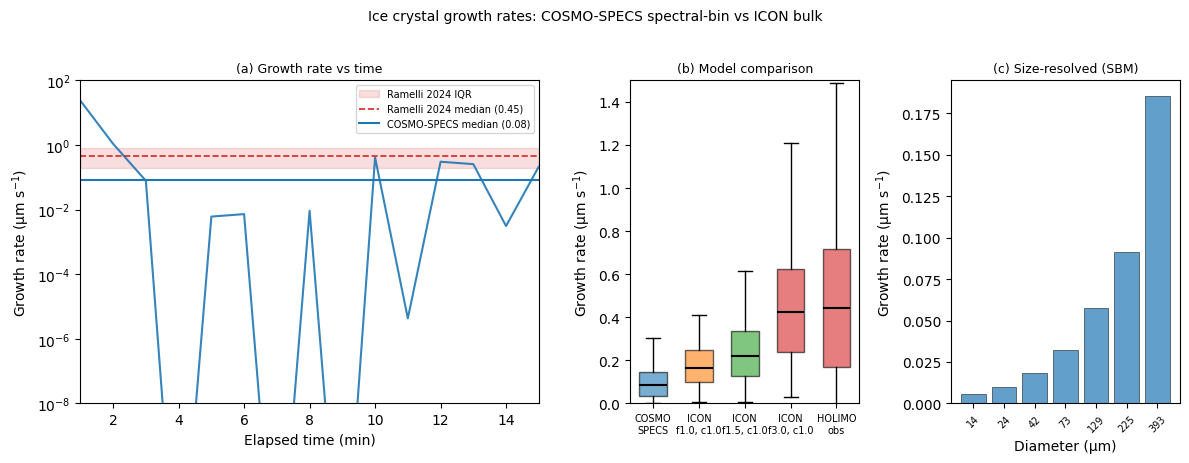

Saved: output/figure_growth_rate_comparison.png


In [31]:
# --- Figure: Growth Rate Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), gridspec_kw={'width_ratios': [2, 1, 1]})

# Panel A: Growth rate vs elapsed time (scatter)
ax = axes[0]
if len(elapsed_mid_all) > 0 and len(growth_rates_all) > 0:
    t_mask = (elapsed_mid_all > 1) & (elapsed_mid_all < 15)
    print(f't_mask shape: {t_mask.shape}')
    print(f'growth_rates_all shape: {growth_rates_all.shape}')
    sc = ax.plot(growth_rates_all, alpha=0.9)

# Ramelli range
ax.axhspan(RAMELLI_GR['p25'], RAMELLI_GR['p75'], alpha=0.15, color='C3',label=f"Ramelli 2024 IQR")
ax.axhline(RAMELLI_GR['median'], color='C3', ls='--', lw=1.2, label=f"Ramelli 2024 median ({RAMELLI_GR['median']:.2f})")

# COSMO-SPECS median
if len(growth_rates_all) > 0:
    med_gr = np.nanmedian(growth_rates_all)
    ax.axhline(med_gr, color='C0', ls='-', lw=1.5,label=f"COSMO-SPECS median ({med_gr:.2f})")
ax.set(xlabel='Elapsed time (min)', ylabel='Growth rate (µm s$^{-1}$)',xlim=(1, 15), ylim=(1e-8, 1e2), yscale='log')
ax.legend(fontsize=7, loc='upper right')
ax.set_title('(a) Growth rate vs time', fontsize=9)

# Panel B: Box plot comparison (COSMO-SPECS vs Omanovic configurations)
ax = axes[1]
bp_data = []
bp_labels = []
bp_colors = []
if len(growth_rates_all) > 0:
    bp_data.append(growth_rates_all)
    bp_labels.append('COSMO\nSPECS')
    bp_colors.append('C0')
    
for i, (lbl, vals) in enumerate(OMANOVIC_GR.items()):
    # Synthesize approximate distribution from percentiles for visual comparison
    synth = np.random.normal(vals['median'], (vals['p75'] - vals['p25']) / 1.35, size=200)
    synth = synth[synth > 0]
    bp_data.append(synth)
    short_lbl = lbl.split('(')[1].rstrip(')')
    bp_labels.append(f'ICON\n{short_lbl}')
    bp_colors.append(f'C{i+1}')
bp_data.append(np.random.normal(RAMELLI_GR['median'], (RAMELLI_GR['p75'] - RAMELLI_GR['p25']) / 1.35, size=200))
bp_labels.append('HOLIMO\nobs')
bp_colors.append('C3')

if len(bp_data) > 0:
    bplot = ax.boxplot(bp_data, positions=range(len(bp_data)), widths=0.6, patch_artist=True, showfliers=False, medianprops={'color': 'k', 'lw': 1.5})
    for patch, color in zip(bplot['boxes'], bp_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
ax.set_xticks(range(len(bp_labels)))
ax.set_xticklabels(bp_labels, fontsize=7)
ax.set(ylabel='Growth rate (µm s$^{-1}$)', ylim=(0, 1.5))
ax.set_title('(b) Model comparison', fontsize=9)

# Panel C: Growth rate by diameter bin (spectral advantage)
ax = axes[2]
diam_edges = np.logspace(np.log10(10), np.log10(500), 8)
diam_mids = (diam_edges[:-1] + diam_edges[1:]) / 2

# Compute growth rate per diameter range from the time-diameter PSD
gr_by_bin = []

# Handle generalized dimensions
extra_dims = [d for d in nf.dims if d not in ('time', 'diameter')]
nf_std = nf.transpose(*(['time'] + extra_dims + ['diameter']))

import itertools
ranges = [range(nf_std.sizes[d]) for d in extra_dims]
if not ranges:
    ranges = [[0]]  # dummy range for no extra dims

for i_bin in range(len(diameters)):
    for idxs in itertools.product(*ranges):
        if extra_dims:
            slc = (slice(None),) + idxs + (i_bin,)
        else:
            slc = (slice(None), i_bin)
            
        col = nf_std.values[slc]
        peaks = np.where(col > 0)[0]
        if len(peaks) < 2:
            continue
        # Growth rate approximated from concentration-weighted diameter shift
        t_first, t_last = peaks[0], peaks[-1]
        dt_bin = elapsed_s[t_last] - elapsed_s[t_first]
        if dt_bin > 0:
            gr_by_bin.append((diameters[i_bin], diameters[i_bin] / (dt_bin + 1e-10)))

if gr_by_bin:
    gr_arr = np.array(gr_by_bin)
    # Bin the growth rates by diameter
    binned_gr = []
    for lo, hi in zip(diam_edges[:-1], diam_edges[1:]):
        mask_d = (gr_arr[:, 0] >= lo) & (gr_arr[:, 0] < hi)
        if mask_d.sum() > 0:
            binned_gr.append(np.nanmedian(gr_arr[mask_d, 1]))
        else:
            binned_gr.append(np.nan)
    ax.bar(range(len(diam_mids)), binned_gr, color='C0', alpha=0.7, edgecolor='k', lw=0.5)
    ax.set_xticks(range(len(diam_mids)))
    ax.set_xticklabels([f'{d:.0f}' for d in diam_mids], fontsize=7, rotation=45)
    ax.set(xlabel='Diameter (µm)', ylabel='Growth rate (µm s$^{-1}$)')
ax.set_title('(c) Size-resolved (SBM)', fontsize=9)

fig.suptitle('Ice crystal growth rates: COSMO-SPECS spectral-bin vs ICON bulk', fontsize=10, y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_growth_rate_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'figure_growth_rate_comparison.png'}")